# Week 6: Constraint-Guided Symbolic Discovery\n
\n
In this notebook, we look for **Physical Laws** inside the regimes.\n
\n
## Hypothesis\n
- **Gating Network** handles Geography (Where/When).\n
- **Experts** should handle Physics (What).\n
\n
## Method\n
- We cluster data into regimes.\n
- For each regime, we run **PySR** with specific constraints:\n
    1. **Inputs**: ONLY Physical (SST, SSS, Chlorophyll). NO Latitude/Longitude.\n
    2. **Operators**: Simple algebraic + exponential (for Arrhenius terms).\n
    3. **Complexity**: Low to prevent overfitting.

In [1]:
import sys
import os
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
from pysr import PySRRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score

sys.path.append(os.path.abspath('..'))

from scripts.preprocess import TRAIN_OUTPUT_PATH

# 1. Load Data
ds_train = xr.open_dataset(TRAIN_OUTPUT_PATH)
df = ds_train.to_dataframe().reset_index().dropna()

# Sample for Symbolic Regression (it's slow on 1M points)
N_SAMPLES = 5000
df_sample = df.sample(n=N_SAMPLES, random_state=42)

# Define Features
# EXPERT INPUTS: STRICTLY PHYSICAL
X_phys = df_sample[['sst', 'sss', 'log_chl']].values
y = df_sample['fco2'].values

# FOR CLUSTERING: We can use Space+Phys to define regimes (like Gating did)
df_sample['lat_norm'] = df_sample['lat'] / 90.0
X_cluster = df_sample[['lat_norm', 'sst', 'sss', 'log_chl']].values

# 2. Define Regimes (Hard Clustering for clean equation finding)
N_REGIMES = 3
kmeans = KMeans(n_clusters=N_REGIMES, random_state=42).fit(X_cluster)
labels = kmeans.labels_

print(f"Data split into {N_REGIMES} regimes.")

c:\Users\shlok\OneDrive\Desktop\Projects\climate-equation-discovery\venv\Lib\site-packages\juliacall\__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Data split into 3 regimes.


In [2]:
# 3. Run Constrained Discovery
equations = {}

for k in range(N_REGIMES):
    print(f"\n--- Discovering Law for Regime {k} ---")
    mask = (labels == k)
    X_k = X_phys[mask]
    y_k = y[mask]
    
    if len(y_k) < 50: 
        print("Too few points, skipping.")
        continue
    
    model = PySRRegressor(
        niterations=30,  # Fast run for demo
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["exp"], # For Arrhenius limits
        # contraints={'exp': 9, '/': 9}, # Soft limits if needed
        temp_equation_file=True,
        verbosity=0
    )
    
    model.fit(X_k, y_k)
    
    print(f"Regime {k} Best Equation:")
    print(model.sympy())
    equations[k] = model

print("\nDiscovery Complete.")


--- Discovering Law for Regime 0 ---


c:\Users\shlok\OneDrive\Desktop\Projects\climate-equation-discovery\venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Regime 0 Best Equation:
x1*(x1*x2 - 1*(-8.074312)) + 355.2333

--- Discovering Law for Regime 1 ---


c:\Users\shlok\OneDrive\Desktop\Projects\climate-equation-discovery\venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Regime 1 Best Equation:
x0*19.286106 + 375.63467

--- Discovering Law for Regime 2 ---


c:\Users\shlok\OneDrive\Desktop\Projects\climate-equation-discovery\venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Regime 2 Best Equation:
x0*16.724636 + 365.20526

Discovery Complete.


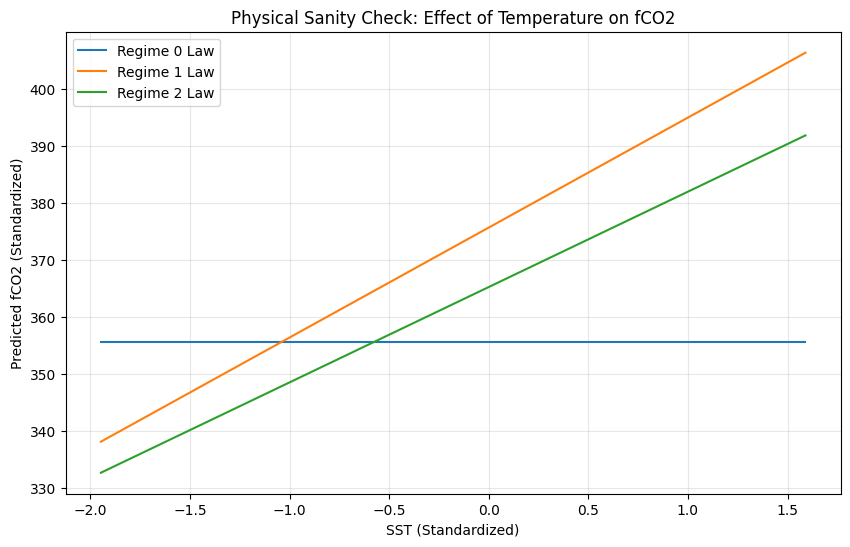

Look for Positive Slopes! (Henry's Law: Higher Temp -> Higher fCO2)


In [3]:
# 4. Evaluate Physical Plausibility
# We check if fCO2 increases with Temperature (Thermodynamics says it should)

# Create synthetic temperature sweep
sst_sweep = np.linspace(df['sst'].min(), df['sst'].max(), 100)
sss_mean = df['sss'].mean()
chl_mean = df['log_chl'].mean()

X_sweep = np.column_stack([
    sst_sweep, 
    np.full_like(sst_sweep, sss_mean), 
    np.full_like(sst_sweep, chl_mean)
])

plt.figure(figsize=(10, 6))
for k, model in equations.items():
    y_pred = model.predict(X_sweep)
    plt.plot(sst_sweep, y_pred, label=f"Regime {k} Law")

plt.xlabel("SST (Standardized)")
plt.ylabel("Predicted fCO2 (Standardized)")
plt.title("Physical Sanity Check: Effect of Temperature on fCO2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Look for Positive Slopes! (Henry's Law: Higher Temp -> Higher fCO2)")